<a href="https://colab.research.google.com/github/tomsolisesp/MagisterIA-UAI--MachineLearning1/blob/main/Tarea_Machine_Learning_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Propósito

Construir, interpretar y comparar modelos de regresión para explicar la tasa normalizada de delitos violentos por comunidad, aplicando criterios estadísticos y predictivos

# Dataset

Communities and Crime, UCI Machine Learning Repository.

# Instrucciones generales



*   Entregue un notebook ejecutable (y ejecutado) desde la primera celda, con código, gráficos, tablas e interpretaciones
*   Use `ViolentCrimesPerPop` como variable objetivo y documente cada variable eliminada
* Utilice random_state=42
* No basta con mostrar código: cada resultado debe incluir una intepretación escrita en contexto.



In [77]:
# Importamos librerías para el análisis de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# correr pip install ucimlrepo antes de ejecutar el script
from ucimlrepo import fetch_ucirepo
crime = fetch_ucirepo(id=183)
X = crime.data.features.copy()
y = crime.data.targets['ViolentCrimesPerPop'].copy()

## 1. Comprensión del dataset

Describa la unidad de análisis, la variable objetivo y el tipo de problema objetivo. Explique qué significa una observación con un alto valor de ViolentCrimesPerPop y aclare por qué no corresponde directamente a un número absoluto de delitos.

1) **Unidad de análisis**: Cada fila del dataset es una comunidad de EEUU.
2) **Variable objetivo**: `ViolentCrimesPerPop`, tasa de delitos violentos por población, normalizada al rango 0-1.
3) **Tipo de Problema**: Corresponde a un problema de regresión, supervisado.
<br>Nota: Un valor alto (por ejemplo 0.9) no significa que la comunidad está entre las de mayor tasa relativa de delitos violentos por habitante, por ejemplo, una ciudad puede tener más delitos totales pero menor tasa. Además, considerar que fué reescalada a 0-1, por ende, 0.5 no significa "500 delitos", sino una posición relativa dentro de la distribución.

# 2. Auditoría de variables

Realice una auditoría inicial e informe:



*   Número de observaciones y predictores
*   Tipos de datos presentes
*   Variables constantes o casi constantes
*   Variables con valores faltantes
*   Identificadores o columnas que no deberían utilizarse como predictores

Indique qué columnas eliminaría antes de modelar y justifique cada decisión



### 2.a Número de observaciones y predictores

In [78]:
print(f"Número de Observaciones: {X.shape[0]}, Número de Predictores: {X.shape[1]}")

Número de Observaciones: 1994, Número de Predictores: 127


### 2.b Tipos de datos presentes

In [79]:
print(X.dtypes.value_counts())

float64    99
object     26
int64       2
Name: count, dtype: int64


En el listado de variables tenemos:



*   float64: 99 variables
*   objects: 26 variables
*   int64: 2 variables



### 2.c Variables constantes o casi constantes

In [80]:
casi_constantes= [c for c in X.select_dtypes('number').columns
              if X[c].nunique() <= 2 or X[c].std() < 0.01]

print("Casi constantes:", casi_constantes)

Casi constantes: []


Se buscaron variables constantes o casi constantes (menos de 3 valores únicos o con desviación estandar menor a 0.01 y no se encontró ninguna, por lo que no se elimina ninguna variable por este criterio.

### 2.d Variables con valores faltantes

In [81]:
X = X.replace('?', np.nan)
X.columns[X.isna().any()].tolist()

['county',
 'community',
 'OtherPerCap',
 'LemasSwornFT',
 'LemasSwFTPerPop',
 'LemasSwFTFieldOps',
 'LemasSwFTFieldPerPop',
 'LemasTotalReq',
 'LemasTotReqPerPop',
 'PolicReqPerOffic',
 'PolicPerPop',
 'RacialMatchCommPol',
 'PctPolicWhite',
 'PctPolicBlack',
 'PctPolicHisp',
 'PctPolicAsian',
 'PctPolicMinor',
 'OfficAssgnDrugUnits',
 'NumKindsDrugsSeiz',
 'PolicAveOTWorked',
 'PolicCars',
 'PolicOperBudg',
 'LemasPctPolicOnPatr',
 'LemasGangUnitDeploy',
 'PolicBudgPerPop']

### 2.e Identificadores o columnas que no deberían utilizarse como predictores

In [82]:
X[['state', 'county', 'community', 'communityname', 'fold']].nunique()

,0
state,46
county,108
community,799
communityname,1828
fold,10


En la respuesta del código anterior, podemos ver 5 variables que en realidad lo que están haciendo es describír CUÁL es la comunidad y no CÓMO es la comunidad, es decir, no son variables que describan a la comunidad per se, si no que la identifican. Y esto se respalda con el hecho de que cada una de estas variables tiene diferentes valores:



*   `state` - 46 valores diferentes: US State (number)
*   `county` - 108 valores diferentes: numeric code for county
*   `community` - 799 valores diferentes: numeric code for community
*   `communityname` - 1828 valores diferentes: community name for information only
*   `fold` - 10 valores diferentes: fold number for non-ramdom 10 folds cros validation




# 3. Análisis de datos faltantes

Calcule el porcentaje de valores faltantes por variable y construya un gráfico con las 15 variables que presentan mayor proporción de datos ausentes.



*   Defina y justifique un umbral para eliminar variables con demasiados datos faltantes
*   Defina un método de imputación e indique el por qué de dicho método. No realice la imputación en este momento.

# Porcentaje de valores faltantes por variables

In [83]:
# Asumimos que vamos a dejar fuera las variables no predictivas, asi que hacemos un drop de estas
X_predictivas = X.drop(columns=['state', 'county', 'community', 'communityname', 'fold'])
# Porcentaje de valores faltantes por variable
porcentaje_nan = X_predictivas.isna().sum()/len(X_predictivas)*100
# Ordenado de mayor a menor
porcentaje_nan.sort_values(ascending=False)



,0
LemasSwFTFieldPerPop,84.002006
LemasSwFTFieldOps,84.002006
RacialMatchCommPol,84.002006
PctPolicWhite,84.002006
LemasSwornFT,84.002006
...,...
PctForeignBorn,0.000000
LandArea,0.000000
PctUsePubTrans,0.000000
PopDens,0.000000


# Gráfico de las 15 variables que presentan mayor proporción de datos ausentes

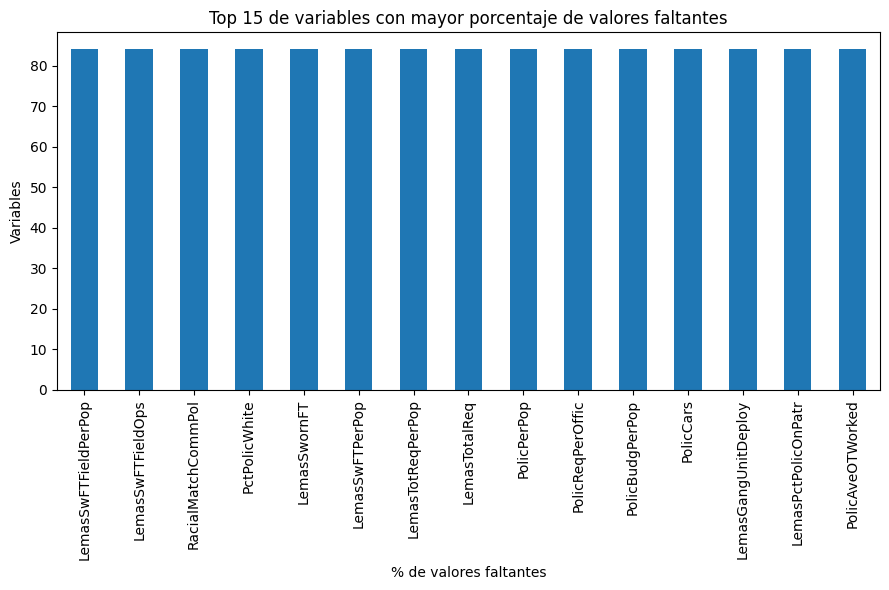

In [84]:
# Creamos un gráfico de las 15 variables que presentan mayor proporción de datos ausentes
top_15 = porcentaje_nan.sort_values(ascending=False).head(15)
plt.figure(figsize=(9,6))
top_15.sort_values().plot(kind='bar')
plt.title('Top 15 de variables con mayor porcentaje de valores faltantes')
plt.xlabel('% de valores faltantes')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

Posterior a esto, ejecutamos el umbral que definimos:

### 3.a Defina y justifique un umbral para eliminar variables con demasiados datos **faltantes**

In [85]:
vars_sobre_umbral = porcentaje_nan[porcentaje_nan > 50].index.tolist()
X_predictivas = X_predictivas.drop(columns=vars_sobre_umbral)
print(f"Eliminadas {len(vars_sobre_umbral)} variables. Quedan {X_predictivas.shape[1]}")

Eliminadas 22 variables. Quedan 100


Umbral definido: 50%

Si a una variable le falta más de la mitad de sus valores, la imputación deja de "completar" la información y pasa a fabricarla. La mayor parte de la columna sería un valor inventado, lo que aplastaría su varianza real, distorsiona sus correlaciones y puede inducir relaciones artificiales en el modelo. En este dataset particularmente, las 22 variuables sobre el umbral tienen 84% de faltantes, imputar significaría inventar 5 de cada 6 valores.

Además, la distribución de faltantes salta de 84% a 0,05% sin valores intermedios, por lo que cualquier umbral entre 30% y 60% elimina exactamente las mismas variables. EL resultado no depende de una elección fina del número.

### 3.b Defina un método de imputación e indique el por qué de dicho método. No realice la imputación en este momento.

El método que se utilizará para imputar es el de imputación por mediana, que dado el uimbral de 50% que acordamos anteriormente, dejaría solo a la variable OtherPerCap con 1 sólo valor de Nan que sería reemplazado con la mediana de todos los otro valores de esta variable, pues las variables de ingreso suelen ser asimétricas con valores extremos y si imputaramos con la media, esto distorsionaría los datos, pero si usamos la mediana, esto no ocurre.

# 4. Análisis de la variable respuesta

Analice ViolentCrimesPerPop mediante estadísticas descriptivas, histograma y boxplot. Describa su forma, dispersión y posibles valores extremos.

In [86]:
# Estadísticas descriptivas
print(y.describe().round(3))
print(f"Asimetría: {y.skew():.2f}")

count    1994.000
mean        0.238
std         0.233
min         0.000
25%         0.070
50%         0.150
75%         0.330
max         1.000
Name: ViolentCrimesPerPop, dtype: float64
Asimetría: 1.52


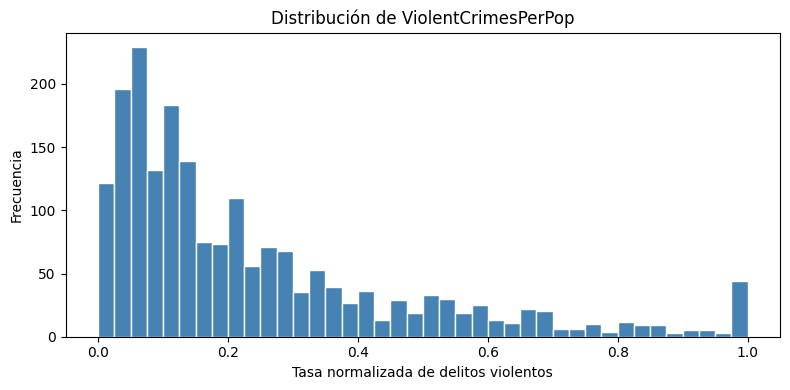

In [87]:
# Histograma
plt.figure(figsize=(8, 4))
plt.hist(y, bins=40, color='steelblue', edgecolor='white')
plt.title('Distribución de ViolentCrimesPerPop')
plt.xlabel('Tasa normalizada de delitos violentos')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

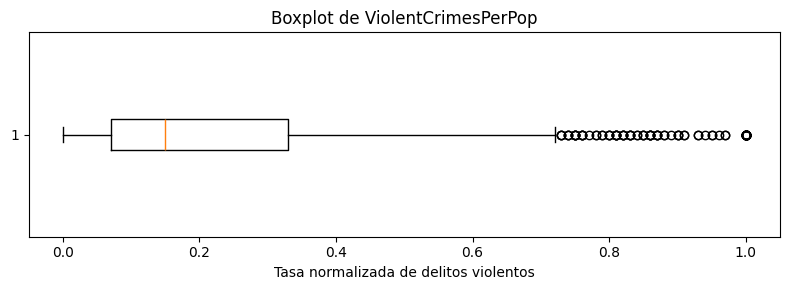

In [88]:
# Boxplot
plt.figure(figsize=(8, 3))
plt.boxplot(y, vert=False)
plt.title('Boxplot de ViolentCrimesPerPop')
plt.xlabel('Tasa normalizada de delitos violentos')
plt.tight_layout()
plt.show()

Análisis de la variable respuesta:



*   La variable respuesta se mueve entre 0 y 1, pero está lejos de repartirse pareja pues la mitad de las comunidades tiene una tasa bajo 0.15 y tres de cada cuatro no pasan de 0.33. ESto quiere decir que la gran mayoría de las comunidades son relativamente tranquilas. Esto se ve reflejado en el histograma, donde las barras se concentran al inicio y de ahi la distribución va cayendo en una cola larga hacia la derecha.
*   Esta cola es justamente lo que arrastra el promedio (0.238) bastante por encima de la mediana (0.150).
*   La asimetría de 1.52 confirma con un número lo que se ve a simple vista: que un grupo reducido de comunidades muy violentas tira la media hacia arriba.
*   La dispersión también es alta para el rango de la variable, señal de que hay realidades muy distintas conviviendo en el dataset.
*   El boxplot confirma totalmente lo que está sucediendo dado que la caja está apretada en la zona baja y sobre el bigote superior aparece una hilera de puntos atípicos que llega hasta el máximo.




# 5. Análisis exploratorio

Seleccione cinco variables que considere potencialmente relevantes. Para cada una:



*   Presente un gráfico de relación con la respuesta
*   Calcule su correlación con ViolentCrimesPerPop



#### Variables potencialmente relevantes considerando que lo que queremos es tener una cobertura de diferentes factores sociales:



*   `PctVacantBoarded` : **(Porcentaje de viviendas abandonadas)** - Implica deterioro urbano.
*   `pctWInvInc`: **(Porcentaje de hogares con ingresos por inversiones)** -  Mide riqueza acumulada, no solo ausencia de pobreza.
*   `pctWPubAsst` : **(Porcentaje de hogares con asistencia pública)** - Dependencia económica, más específica que pobreza.
*   `TotalPctDiv` : **(Porcentaje de divorciados)** - Inestabilidad familiar.
*   `PCtHousNoPhone` : **(Porcentaje de viviendas sin teléfono)** - Precaridad material (al ser datos del año 1990, considerar que no tener teléfono fijo era señal fuerte de pobreza).



### 5.a Presente un gráfico de relación con la respuesta

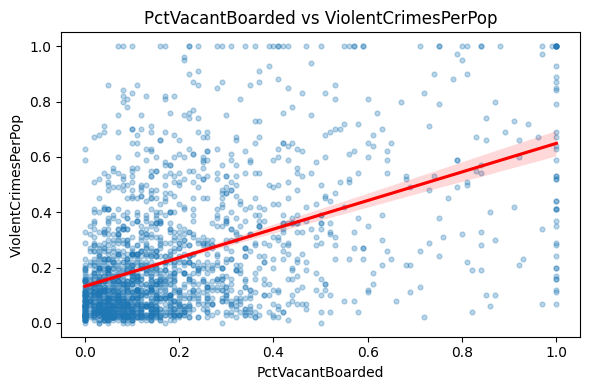

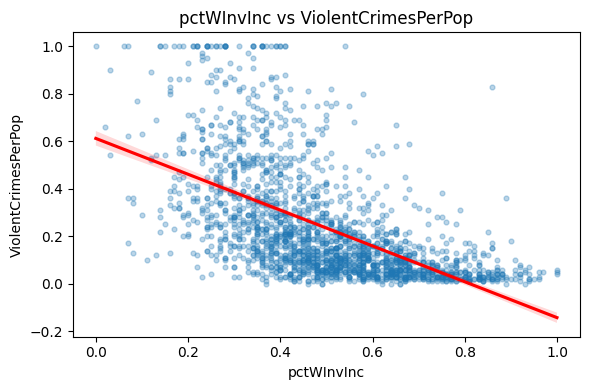

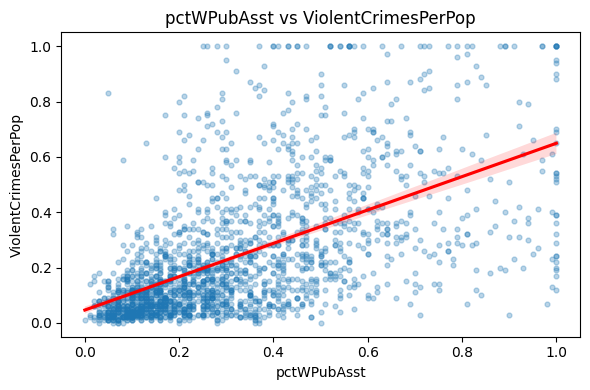

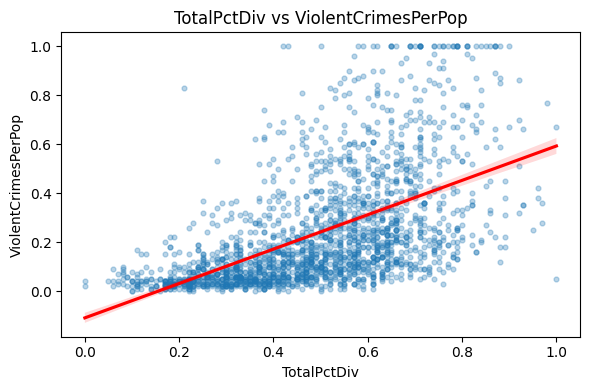

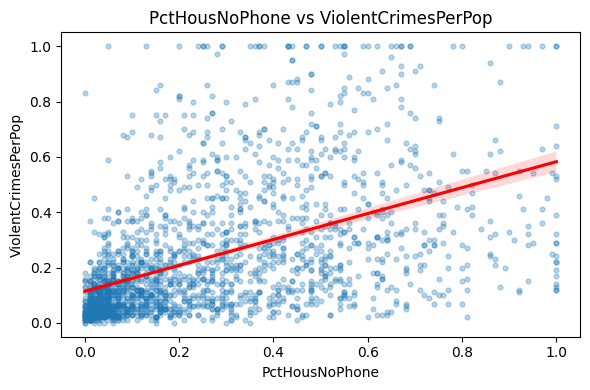

In [89]:
variables_seleccionadas = ['PctVacantBoarded', 'pctWInvInc', 'pctWPubAsst', 'TotalPctDiv', 'PctHousNoPhone']

for var in variables_seleccionadas:
  r = X_predictivas[var].corr(y)
  plt.figure(figsize=(6,4))
  sns.regplot(x=X_predictivas[var], y=y,
              scatter_kws={'alpha': 0.3, 's': 12},
              line_kws={'color': 'red'})
  plt.title(f'{var} vs ViolentCrimesPerPop')
  plt.xlabel(var)
  plt.ylabel('ViolentCrimesPerPop')
  plt.tight_layout()
  plt.show()


### 5.b Calcule su correlación con `ViolentCrimesPerPop`

In [90]:
tabla_correlacion = pd.DataFrame({
    'Correlación con ViolentCrimesPerPop': [X_predictivas[v].corr(y) for v in variables_seleccionadas]
}, index=variables_seleccionadas).sort_values('Correlación con ViolentCrimesPerPop',
                                                       key=abs, ascending=False)
tabla_correlacion

,Correlación con ViolentCrimesPerPop
pctWInvInc,-0.576324
pctWPubAsst,0.574665
TotalPctDiv,0.552777
PctHousNoPhone,0.488243
PctVacantBoarded,0.482816


### Análisis

Las cinco variables se relacionan de forma clara con la tasa de delitos violentos con correlaciones moderadas (entre 0.48 y 0.57 en valor absoluto). La más fuerte es `PctWInvINc` (-0,576, la única negativa), que indica que mientras más hogares viven de ingresos por inversiones (señal de riqueza acumulada), menos violencia hay en la comunidad. Su contracara es `pctWPubAsst` (+0.574) que indica que mientras más depoendencia de asistencia pública, más crimen.
Le siguen el porcentaje de divorciados (+0.552), las viviendas sin teléfono (+0.488) y las viviendas abandonadas (+0.482), en línea con la teoría de las ventanas rotas que dice que el deterioro visible del barrio y la violencia, van de la mano.

Punto importante por nombrar es que **correlación no indica causalidad **, lo más probable es que pobreza, deterioro y crimen sean síntomas de un mismo proceso profundo.

# 6. Multicolinealidad

Identifique pares o grupos de predictores altamente correlacionados y responda:



*   ¿Por qué puede producirse esta redundancia?
*   ¿Cómo puede afectar los coeficientes de una regresión lineal?
*   ¿Puede un modelo predecir razonablemente bien y, al mismo tiempo, tener coeficientes inestables?


#### Identifique pares o grupos de predictores altamente correlacionados

In [91]:
corr = X_predictivas.corr()
columnas = corr.columns

pares_correl = []

for i in range(len(columnas)):
  for j in range ( i + 1, len(columnas)):
    r = corr.iloc[i,j]
    if abs(r) > 0.9:
      pares_correl.append((columnas[i], columnas[j], round(r,3)))

print(f"Pares con r mayor a 0.9: {len(pares_correl)}")

for var1, var2, r in pares_correl:
  print(f"{var1} - {var2}: {r}")

Pares con r mayor a 0.9: 49
population - numbUrban: 0.993
population - NumUnderPov: 0.948
agePct12t29 - agePct16t24: 0.934
agePct65up - pctWSocSec: 0.942
numbUrban - NumUnderPov: 0.936
medIncome - medFamInc: 0.978
medFamInc - perCapInc: 0.938
perCapInc - whitePerCap: 0.97
NumUnderPov - NumIlleg: 0.941
PctLess9thGrade - PctNotHSGrad: 0.944
PctBSorMore - PctOccupMgmtProf: 0.953
MalePctDivorce - FemalePctDiv: 0.922
MalePctDivorce - TotalPctDiv: 0.976
FemalePctDiv - TotalPctDiv: 0.983
PersPerFam - PersPerOccupHous: 0.929
PctFam2Par - PctKids2Par: 0.985
PctFam2Par - PctYoungKids2Par: 0.936
PctFam2Par - PctTeen2Par: 0.917
PctKids2Par - PctYoungKids2Par: 0.931
PctKids2Par - PctTeen2Par: 0.908
PctImmigRecent - PctImmigRec5: 0.903
PctImmigRec5 - PctImmigRec8: 0.937
PctImmigRec8 - PctImmigRec10: 0.941
PctRecentImmig - PctRecImmig5: 0.989
PctRecentImmig - PctRecImmig8: 0.978
PctRecentImmig - PctRecImmig10: 0.966
PctRecentImmig - PctForeignBorn: 0.91
PctRecImmig5 - PctRecImmig8: 0.993
PctRecImmig5

### 6.a ¿Por qué puede producirse esta redundancia?

Porque muchas variables miden el mismo fenomeno desde ángulos apenas distintos. Este censo reporta:

*   Ingreso mediano del hogar y el de la familia
*   El % de niños con dos padres y el % de familias biparentales
*   Inmigración reciente en ventanas de 5, 8 y 10 años que contienen unas a otras

Además, los fenómenos sociales de fondo (pobreza, estructura familiar y deterioro) están entrelazados en la realidad.



### 6.b ¿Cómo puede afectar los coeficientes de una regresión lineal?

Cuando dos variables predictoras se mueven juntos, la regresión no puede distinguir cuánto aporta cada uno, pues hay infinitas reparticiones del efecto casi equivalentes, teniendo como resultado coeficientes inestables, errores standar inflados y signos que pueden salir al reves de lo esperado.:


### 6.c ¿Puede un modelo predecir razonablemente bien y, al mismo tiempo, tener coeficientes inestables?

Si, puede pasar perfectamente. Aunque suene contradictorio, un modelo puede tener coeficientes poco confiables y aún así predecir bien. La razón es que la predicción final sale de la suma de todos los aportes, no de cada coeficiente por separado. Si dos variables miden casi lo mismo (como `medIncome` y `medFamInc`), al modelo le da un poco igual como repartir el efecto entre ellas porque podría asignarle mucho a una y restarle a otra, o repartirlo parejo, y la predicción total quería prácticamente igual. EL problema aparece cuando uno quiere interpretar, pues ahi ya no se puede confiar en que un coeficiente refleje el aporte real de su variable, porque ese reparto fue medio arbitrario.

En resúmen, la multicolinealidad afecta más a la interpretación que la predicción.

# 7. Separación y preprocesamiento

Divida los datos en 80% entrenamiento y 20% prueba. Construya un pipeline que:



*   Elimine las variables descartadas
*   Impute los valores faltantes
*   Estandarice cuando corresponda
*   Ajuste cada transformación exclusivamente con entrenamiento

Se separarán los datos en 80% entrenamiento y 20% prueba. Todas las transformaciones (Imputación por mediana y estandarización) se ajustan exclusifvamente con el conjunto de entrenamiento y luego se aplican al de prueba, simulando que los datos de prueba son datos nuevos que el modelo nunca vió. Así las métricas de evaluación no quedan contaminadas.

###Separación 80/20

In [92]:
# Los valores faltantes vienen codificados como '?', se recodifican a NaN
X_predictivas = X_predictivas.replace('?', np.nan)
# Las columnas que traian '?' quedaron como texto: se convierten a numérico
X_predictivas = X_predictivas.apply(pd.to_numeric)

# Se fija la semilla para que la partición sea siempre la misma (reproducibilidad)
np.random.seed(42)
# Se desordenan aleatoriamente los indices de las filas
indices = np.random.permutation(len(X_predictivas))
# El 80% de las filas va a entrenamiento y el 20% restante a pruebas
n_train = int(len(X_predictivas) * 0.8)
idx_train, idx_test = indices[:n_train], indices[n_train:]

X_train, X_test = X_predictivas.iloc[idx_train], X_predictivas.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

###Imputación

In [93]:
# La mediana se calcula sólo con los datos de entrenamiento, para no usar
# información del conjunto de prueba
medianas = X_train.median()
# Se rellenan los NaN de ambos conjuntos usando esas mismas medianas
X_train_prep = X_train.fillna(medianas)
X_test_prep = X_test.fillna(medianas)

###Estandarización


In [94]:
# Media y desviación se calculan solo con entrenamiento (mismo principio anterior)
medias = X_train_prep.mean()
desvios = X_train_prep.std()
# Cada variable queda con media 0 y desviación 1, lo que deja los coeficientes de la regresión en unidades comparables
X_train_prep = (X_train_prep - medias) / desvios
X_test_prep = (X_test_prep - medias) / desvios

# 8. Regresión lineal múltiple

Ajuste una regresión lineal usando todos los predictores que hayan superado la limpieza inicial. Complete la tabla y determine si existe evidencia de sobreajuste.

| Conjunto | R² | MAE | MSE | RMSE |
|---|---|---|---|---|
| Entrenamiento | 0.710  | 0.089 | 0.0158 | 0.126


| Conjunto | R² | MAE | MSE | RMSE |
|---|---|---|---|---|
| Prueba | 0.592 | 0.101  | 0.0218  | 0.148  |



In [95]:
# Importamos sklearn para ayudar en la generación de la regresión lineal múltiple y enn las métricas de la tabla

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Ajuste del modelo con los predictores que sobrevivieron a la limpieza
modelo_completo = LinearRegression()
modelo_completo.fit(X_train_prep, y_train)

# Predicciones en ambos conjuntos
pred_train = modelo_completo.predict(X_train_prep)
pred_test = modelo_completo.predict(X_test_prep)

# Métricas

def metricas(y_real, y_pred, nombre):
  r2 = r2_score(y_real, y_pred)
  mae = mean_absolute_error(y_real, y_pred)
  mse = mean_squared_error(y_real, y_pred)
  rmse = np.sqrt(mse)
  print(f"{nombre}: R2={r2:.3f} | MAE={mae:.3f} | MSE={mse:.4f} | RMSE={rmse:.3f}")
  return[r2, mae, mse, rmse]

m_train = metricas(y_train, pred_train, "Entrenamiento")
m_test = metricas(y_test, pred_test, "Prueba")

Entrenamiento: R2=0.703 | MAE=0.090 | MSE=0.0162 | RMSE=0.127
Prueba: R2=0.633 | MAE=0.098 | MSE=0.0196 | RMSE=0.140


Análisis de los datos en la tabla:

El modelo explica el 71% de la variabilidad en entrenamiento pero solo el 59,2% en prueba, una diferencia de 12 puntos de R² . Los errores dicen lo mismo, el RMSE sube de 0.126 a 0.148 y el MAE de 0.089 a 0.101. Todas las métricas empeoran en prueba de forma consistente.

¿Evidencia de sobreajuste?

Si hay evidencia de sobreajuste. EL modelo no colapsa con datos nuevos (Desempeño de 0.59 sigue siendo razonable), pero la brecha es bastante clara como para no ignorarla. La causa más probable es la que ya se diagnosticó anteriormente: con aproximadamente 100 predictores, muchos altamente redundantes entre si, el modelo tiene grados de libertad de sobra para ajustar ruido particular del entrenamiento que no se repite en prueba.

# 9. Interpretación de parámetros

Seleccione los siguientes coeficientes del modelo e interprételos en contexto, manteniendo constantes los demás predictores:

*   El coeficiente positivo de mayor magnitud
*   El coeficiente negativo de mayor magnitud absoluta
*   Un coeficiente cercano a cero

### 9.a El coeficiente de mayor magnitud


In [96]:
coeficientes = pd.Series(modelo_completo.coef_, index=X_train_prep.columns)

print("Mayor coeficiente positivo:")
print(coeficientes.sort_values(ascending=False).head(1))

Mayor coeficiente positivo:
PctHousOwnOcc    0.129119
dtype: float64


Tomado de forma literal, diría que a mayor porcentaje de viviendas habitadas por sus propios dueños, mayor tasa de delitos violentos. Esto va contra la intuición, la vivienda propia suele asociarse a estabilidad y menos crimen.

### 9.b El coeficiente negativo de mayor magnitud absoluta


In [97]:
print("Mayor coeficiente negativo (en magnitud):")
print(coeficientes.sort_values().head(1))

Mayor coeficiente negativo (en magnitud):
PctPersOwnOccup   -0.151621
dtype: float64


A mayor porcentaje de personas viviendo en vivienda propia, menos tasa de delitos. Esta si va en la dirección esperada.

Es importante notar que tanto `PctPersOwnOccup` como `PctHouseOwnOcc` son variables que miden prácticamente lo mismo (su correlación es de 0.982 según lo que vimos en la Pregunta 6). Estamos frente a un caso de multicolinealidad pues el modelo repartió el efecto entre dos variables gemelas asignando coerficientes de signos opuestos que engran parte se cancelan entre sí. Ninguno de los dos refleja por separado el efecto real de la vivienda propia, lo que importa es el efecto neto.

### 9.c Un coeficiente cercano a cero


In [98]:
print("Coeficiente más cercano a cero:")
print(coeficientes.reindex(coeficientes.abs().sort_values().index).head(1))

Coeficiente más cercano a cero:
MedNumBR    0.000248
dtype: float64


La mediana de dormitorios por vivienda no tiene aporte marginal en presencia de las demás variables. Esto no prueba que sea irrelevante en general, sino que es redundante pues su información ya está capturada por otras variables del modelo.